In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [6]:
def translate_text(state: SubState):
    prompt = f"""Translate the following text to Urdu,
     Keep it natural and clear do not add any extra content.
     Text : {state["input_text"]}""".strip()

    translated_text =  subgraph_llm.invoke(prompt).content

    return {"translated_text": translated_text}

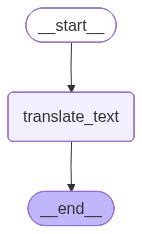

In [7]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node("translate_text", translate_text)

subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

subgraph


In [8]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_urdu: str


In [9]:
parent_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [10]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are a helpful assistant, Answer clearly. \n {state['question']}").content
    return {'answer_eng':answer}

In [11]:
def translate_answer(state: ParentState):
    # Call the subgraph
    result = subgraph.invoke({'input_text':state['answer_eng']})
    return {"answer_urdu":result["translated_text"]}

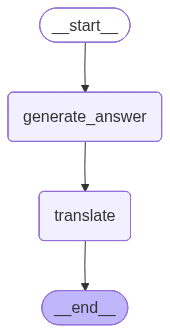

In [12]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node('generate_answer',generate_answer)
parent_builder.add_node('translate', translate_answer)

parent_builder.add_edge(START, 'generate_answer')
parent_builder.add_edge('generate_answer', 'translate')

parent_builder.add_edge('translate',END)

graph = parent_builder.compile()

graph

In [13]:
graph.invoke({'question': "What is an AI Engineer"})

{'question': 'What is an AI Engineer',
 'answer_eng': "An **AI Engineer** is a specialized professional who designs, develops, implements, and maintains artificial intelligence systems and applications. They bridge the gap between AI theory and practical, real-world solutions.\n\nThink of them as the architects and builders of AI products.\n\nHere's a breakdown of what that means:\n\n1.  **Translating Theory into Practice:** They take cutting-edge AI research and algorithms (often developed by AI researchers or data scientists) and turn them into functional, scalable, and robust software applications.\n2.  **Building and Training Models:** They are skilled in selecting, building, training, and optimizing machine learning and deep learning models for specific tasks (e.g., image recognition, natural language processing, predictive analytics).\n3.  **Data Management:** They work extensively with data, including collecting, cleaning, preprocessing, and engineering features to ensure the AI